# Chapter 2. NumPy



*   파이썬에서 수치 계산 및 행렬 연산을 위한 핵심 도구인 NumPy에 대해 학습한다.



# 2.1. The NumPy array object

## 2.1.1. What are NumPy and NumPy arrays?

**Python objects**:

*   수치형 scalar 객체: integers, floats 등
*   컨테이너: lists, dictionaries 등

**NumPy provides**:

*   다차원 배열(array)을 위한 파이썬 확장 패키지
*   하드웨어에 더 가까움(효율성 측면)
*   과학 계산을 위해 설계됨(편의성 측면)  : 브로드캐스팅

In [1]:
import numpy as np
a = np.array([0, 1, 2, 3])
a

array([0, 1, 2, 3])

NumPy array는 다음의 값을 포함할 수 있다:

*   이산적인 시간 단계에서의 실험/시뮬레이션 결과 값
*   측정 장치에 의해 기록된 신호 (예: 음파)
*   이미지의 픽셀 값
*   서로 다른 X-Y-Z 위치에서 측정된 3차원 데이터 (예: MRI 스캔)
*   ...



**NumPy가 유용한 이유:** 메모리 효율적인 컨테이너를 제공하여 빠른 수치 연산을 가능하게 한다.

In [2]:
L = range(1000)
%timeit [i ** 2 for i in L]

29.8 μs ± 390 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [3]:
a = np.arange(1000)
%timeit a ** 2

616 ns ± 1.5 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


**NumPy 참고자료:**

*   On the web: [https://numpy.org/doc/](https://numpy.org/doc/)
*   Interactive help:



In [4]:
np.array?

Signature:
np.array(
    object,
    dtype=None,
    *,
    copy=True,
    order='K',
    subok=False,
    ndmin=0,
    ndmax=0,
    like=None,
)
Docstring:
array(object, dtype=None, *, copy=True, order='K', subok=False, ndmin=0,
      ndmax=0, like=None)

Create an array.

Parameters
----------
object : array_like
    An array, any object exposing the array interface, an object whose
    ``__array__`` method returns an array, or any (nested) sequence.
    If object is a scalar, a 0-dimensional array containing object is
    returned.
dtype : data-type, optional
    The desired data-type for the array. If not given, NumPy will try to use
    a default ``dtype`` that can represent the values (by applying promotion
    rules when necessary.)
copy : bool, optional
    If ``True`` (default), then the array data is copied. If ``None``,
    a copy will only be made if ``__array__`` returns a copy, if obj is
    a nested sequence, or if a copy is needed to satisfy any of the other
    require

In [5]:
help(np.array)

Help on built-in function array in module numpy:

array(
    object,
    dtype=None,
    *,
    copy=True,
    order='K',
    subok=False,
    ndmin=0,
    ndmax=0,
    like=None
)
    array(object, dtype=None, *, copy=True, order='K', subok=False, ndmin=0,
          ndmax=0, like=None)

    Create an array.

    Parameters
    ----------
    object : array_like
        An array, any object exposing the array interface, an object whose
        ``__array__`` method returns an array, or any (nested) sequence.
        If object is a scalar, a 0-dimensional array containing object is
        returned.
    dtype : data-type, optional
        The desired data-type for the array. If not given, NumPy will try to use
        a default ``dtype`` that can represent the values (by applying promotion
        rules when necessary.)
    copy : bool, optional
        If ``True`` (default), then the array data is copied. If ``None``,
        a copy will only be made if ``__array__`` returns a copy, if 

*   Looking for something:

In [6]:
np.con*?

np.concat
np.concatenate
np.conj
np.conjugate
np.convolve

**NumPy를 import할 때 권장되는 관례:**

In [7]:
import numpy as np

## 2.1.2. Creating arrays

**Array를 수동으로 생성하는 방식:**

*   1-D:



In [8]:
a = np.array([0, 1, 2, 3])
a

array([0, 1, 2, 3])

In [9]:
a.ndim

1

In [14]:
np.ndim?

Signature:       np.ndim(a)
Call signature:  np.ndim(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function ndim at 0x10c681c60>
File:            /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/fromnumeric.py
Docstring:      
Return the number of dimensions of an array.

Parameters
----------
a : array_like
    Input array.  If it is not already an ndarray, a conversion is
    attempted.

Returns
-------
number_of_dimensions : int
    The number of dimensions in `a`.  Scalars are zero-dimensional.

See Also
--------
ndarray.ndim : equivalent method
shape : dimensions of array
ndarray.shape : dimensions of array

Examples
--------
>>> import numpy as np
>>> np.ndim([[1,2,3],[4,5,6]])
2
>>> np.ndim(np.array([[1,2,3],[4,5,6]]))
2
>>> np.ndim(1)
0
Class docstring:
Class to wrap functions with checks for __array_function__ overrides.

All arguments are required, and can only be passed by position.

Parameters
-------

In [10]:
a.shape

(4,)

In [11]:
len(a)

4

*   2-D, 3-D, ...:

In [12]:
b = np.array([[0, 1, 3], [3, 4, 5]])    # 2 by 3 array
b

array([[0, 1, 3],
       [3, 4, 5]])

In [13]:
b.ndim

2

In [15]:
b.shape

(2, 3)

In [16]:
len(b)    # returns the size of the first dimension

2

In [17]:
c = np.array([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])
c

array([[[1, 2],
        [3, 4]],

       [[5, 6],
        [7, 8]]])

In [18]:
c.shape

(2, 2, 2)

In [19]:
c[1,0,0]

np.int64(5)

**Array를 생성하는 함수들:**

#### np.arange : step, np.linspace : num-points

*   Evenly spaced:

In [20]:
a = np.arange(10)    # 0, ..., n-1
a

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [21]:
b = np.arange(1, 9, 2)    # start, end (exclusive), step
b

array([1, 3, 5, 7])

*   By the number of points:

In [22]:
c = np.linspace(0, 1, 6)    # start, end, num-points
c

array([0. , 0.2, 0.4, 0.6, 0.8, 1. ])

In [23]:
d = np.linspace(0, 1, 5, endpoint=False)
d

array([0. , 0.2, 0.4, 0.6, 0.8])

*   Common arrays:

In [24]:
a = np.ones((3, 3))    # reminder: (3, 3) is a tuple
a

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])

In [25]:
b = np.zeros((2, 2))
b

array([[0., 0.],
       [0., 0.]])

In [26]:
c = np.eye(3)
c

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [27]:
d = np.diag(np.array([1, 2, 3, 4]))
d

array([[1, 0, 0, 0],
       [0, 2, 0, 0],
       [0, 0, 3, 0],
       [0, 0, 0, 4]])

In [28]:
np.diag?

Signature:       np.diag(v, k=0)
Call signature:  np.diag(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function diag at 0x10c73a0c0>
File:            /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_twodim_base_impl.py
Docstring:      
Extract a diagonal or construct a diagonal array.

See the more detailed documentation for ``numpy.diagonal`` if you use this
function to extract a diagonal and wish to write to the resulting array;
whether it returns a copy or a view depends on what version of numpy you
are using.

Parameters
----------
v : array_like
    If `v` is a 2-D array, return a copy of its `k`-th diagonal.
    If `v` is a 1-D array, return a 2-D array with `v` on the `k`-th
    diagonal.
k : int, optional
    Diagonal in question. The default is 0. Use `k>0` for diagonals
    above the main diagonal, and `k<0` for diagonals below the main
    diagonal.

Returns
-------
out : ndarray
    The extracted diag

In [ ]:
np.diag(np.array([1, 2]), k = 2) #diagonal above the main diagonal

array([[0, 0, 1, 0],
       [0, 0, 0, 2],
       [0, 0, 0, 0],
       [0, 0, 0, 0]])

In [30]:
np.diag(np.array([1, 2, 3]), k = -1)

array([[0, 0, 0, 0],
       [1, 0, 0, 0],
       [0, 2, 0, 0],
       [0, 0, 3, 0]])

*   **np.random:** 난수 생성 (Mersenne Twister PRNG):

In [31]:
rng = np.random.default_rng(27446968)
a = rng.random(4)    # uniform in [0, 1]
a

array([0.64613018, 0.48984931, 0.50851229, 0.22563948])

In [32]:
b = rng.standard_normal(4)    # standard Gaussian
b

array([-0.38250769, -0.61536465,  0.98131732,  0.59353096])

In [33]:
np.random?

Type:        module
String form: <module 'numpy.random' from '/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/random/__init__.py'>
File:        /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/random/__init__.py
Docstring:  
Random Number Generation

Use ``default_rng()`` to create a `Generator` and call its methods.

=============== =========================================================
Generator
--------------- ---------------------------------------------------------
Generator       Class implementing all of the random number distributions
default_rng     Default constructor for ``Generator``
=============== =========================================================

============================================= ===
BitGenerator Streams that work with Generator
--------------------------------------------- ---
MT19937
PCG64
PCG64DXSM
Philox
SFC64
============================================= ===

==========

## 2.1.3. Basic data types

때때로 array의 원소가 뒤에 점이 붙어서 표시되는 것을 볼 수 있다(예를 들어 2. vs 2). 이는 사용된 데이터 타입의 차이 때문이다:

In [34]:
a = np.array([1, 2, 3])
a.dtype

dtype('int64')

In [35]:
b = np.array([1., 2., 3.])
b.dtype

dtype('float64')

서로 다른 데이터 타입을 사용함으로써 메모리에 데이터를 더 효율적으로 저장할 수 있지만, 대부분의 경우 우리는 단순히 부동소수점 숫자(floating-point numbers)를 사용한다.   
위의 예시에서 볼 수 있듯이, NumPy는 입력값으로부터 데이터 타입을 자동으로 감지한다.

원하는 데이터 타입을 명시적으로 지정할 수도 있다:

In [36]:
c = np.array([1, 2, 3], dtype = float)
c.dtype

dtype('float64')

기본 데이터 타입은 float이다:

In [38]:
a = np.ones((3, 3))
a.dtype

dtype('float64')

이외에도 다양한 데이터 타입이 존재한다:

*   **Complex:**

In [37]:
d = np.array([1+2j, 3+4j, 5+6*1j])
d.dtype

dtype('complex128')

*   **Bool:**

In [39]:
e = np.array([True, False, False, True])
e.dtype

dtype('bool')

*   **Strings:**

In [41]:
f = np.array(['Bonjour', 'Hello', 'Hallo'])
f.dtype    # <--- strings containing max. 7 letters

dtype('<U7')

## 2.1.4. Basic visualization

이제 array를 간단히 시각화해보자.

먼저 주피터 노트북에서 plot이 표시되도록 활성화하자. `inline` 옵션은 plot이 새 창이 아닌 노트북 안에 표시되도록 한다.

In [42]:
%matplotlib inline

Matplotlib은 2D 그래프를 그리기 위한 파이썬 패키지이다. 아래와 같이 그 기능들을 불러올 수 있다:

In [43]:
import matplotlib.pyplot as plt

*   **1D plotting:**

In [44]:
x = np.linspace(0, 3, 20)
y = np.linspace(0, 9, 20)
x, y

(array([0.        , 0.15789474, 0.31578947, 0.47368421, 0.63157895,
        0.78947368, 0.94736842, 1.10526316, 1.26315789, 1.42105263,
        1.57894737, 1.73684211, 1.89473684, 2.05263158, 2.21052632,
        2.36842105, 2.52631579, 2.68421053, 2.84210526, 3.        ]),
 array([0.        , 0.47368421, 0.94736842, 1.42105263, 1.89473684,
        2.36842105, 2.84210526, 3.31578947, 3.78947368, 4.26315789,
        4.73684211, 5.21052632, 5.68421053, 6.15789474, 6.63157895,
        7.10526316, 7.57894737, 8.05263158, 8.52631579, 9.        ]))

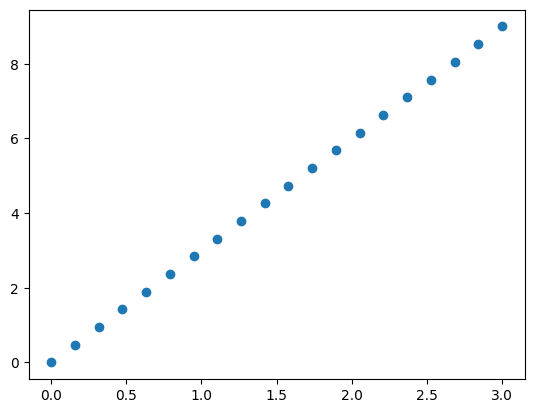

In [45]:
plt.plot(x, y, 'o')    # dot plot

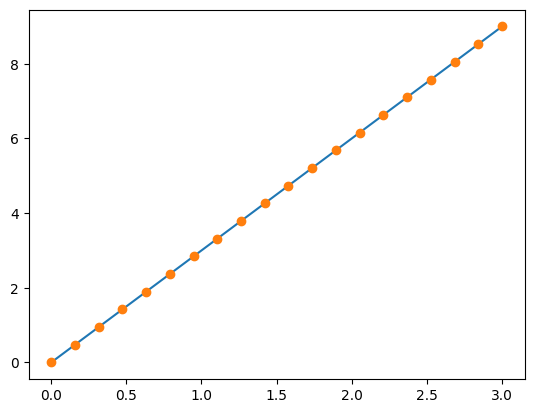

In [46]:
plt.plot(x, y)
plt.plot(x, y, 'o')

*   **2D arrays (예: 이미지):**

In [47]:
rng = np.random.default_rng(27446968)
image = rng.random((30, 30))
image

array([[6.46130180e-01, 4.89849310e-01, 5.08512288e-01, 2.25639476e-01,
        2.75678308e-01, 5.36568353e-01, 8.10553794e-01, 9.22068613e-01,
        2.69395612e-01, 6.31718603e-01, 2.19917589e-01, 9.48300061e-01,
        1.72071042e-01, 1.30884822e-01, 5.83397077e-01, 2.71980911e-01,
        7.65430446e-01, 7.83975071e-01, 7.34051881e-01, 9.97424916e-01,
        3.89545014e-01, 2.75598875e-01, 9.42044881e-01, 8.54922228e-01,
        6.45366583e-01, 4.15197619e-01, 3.18555962e-01, 5.85070236e-01,
        7.34639249e-01, 6.13520833e-01],
       [9.70032979e-01, 3.58502442e-01, 2.53046795e-01, 1.07206455e-01,
        6.86809984e-01, 3.77800270e-01, 2.45716299e-01, 3.63852622e-01,
        7.08657533e-01, 4.82685382e-01, 6.14345191e-01, 3.64518782e-01,
        4.86914655e-01, 8.14195178e-01, 5.48702370e-01, 5.16049167e-01,
        5.96828802e-01, 1.49206838e-01, 3.87213985e-01, 8.30706082e-01,
        1.29859023e-01, 8.33424897e-01, 3.90370787e-01, 7.95093918e-01,
        6.84641802e-01,

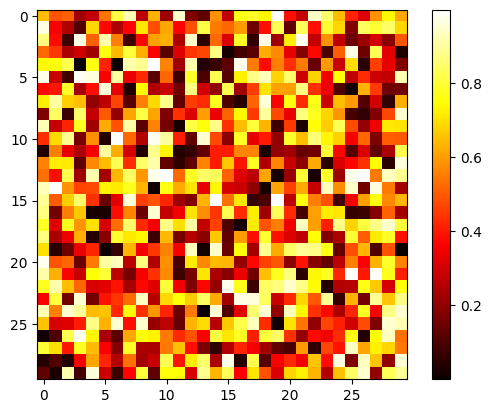

In [ ]:
plt.imshow(image, cmap=plt.cm.hot) #heatmap 
plt.colorbar()

## 2.1.5. Indexing and slicing

Array의 요소는 다른 파이썬 시퀀스(예: 리스트)와 동일한 방식으로 접근하거나 할당할 수 있다.

list는 one dimension 이었으나 이젠 

In [49]:
a = np.arange(10)
a

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [50]:
a[0], a[2], a[-1]

(np.int64(0), np.int64(2), np.int64(9))

**주의: 인덱스는 다른 파이썬 시퀀스들(그리고 C/C++처럼)과 마찬가지로 0부터 시작한다. 반면에, Fortran이나 Matlab에서는 인덱스가 1부터 시작한다.**

In [ ]:
a[1:6:2]   # start, end (exclusive), step

array([1, 3, 5])

시퀀스를 역순으로 만드는 일반적인 파이썬 방식 또한 지원된다:

In [53]:
a[::-1]

array([9, 8, 7, 6, 5, 4, 3, 2, 1, 0])

다차원 array의 경우, 인덱스는 정수로 이루진 튜플이다:

In [54]:
a = np.diag(np.arange(3))
a

array([[0, 0, 0],
       [0, 1, 0],
       [0, 0, 2]])

In [ ]:
print(a[1, 1]) # 자동으로 tuple로 인식

1


In [ ]:
print(a[(1,1)]) # 명시적으로 tuple로 인식

1


In [59]:
a[2, 1] = 10    # third line, second columns
a

array([[ 0,  0,  0],
       [ 0,  1,  0],
       [ 0, 10,  2]])

In [60]:
a[1]

array([0, 1, 0])

In [61]:
a[0]

array([0, 0, 0])

**참고:**

*   2차원에서는 첫 번째 차원이 행(rows), 두 번째 차원이 열(columns)에 해당한다.
*   다차원 array `a`에서 `a[i]`는 지정되지 않은 차원의 모든 요소를 포함하는 것으로 해석된다.


**슬라이싱:** array도 다른 파이썬 시퀀스들처럼 슬라이싱할 수 있다:

In [83]:
a = np.arange(10)
a

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [ ]:
a[2:9:3]    # [start:end:step]. #end는 포함되지 않는다. (9 제외 )

array([2, 5, 8])

마지막 인덱스는 포함되지 않는다는 점을 유의하자!

In [64]:
a[:4]

array([0, 1, 2, 3])

세 가지 슬라이싱의 구성 요소는 모두 필수가 아니다: 디폴트값은 start는 0, end는 마지막 요소, step은 1이다:

In [65]:
print(a[1:3])
print(a[::2])
print(a[3:])

[1 2]
[0 2 4 6 8]
[3 4 5 6 7 8 9]


**NumPy 인덱싱과 슬라이싱에 대한 간단한 그림 요약:** <br>

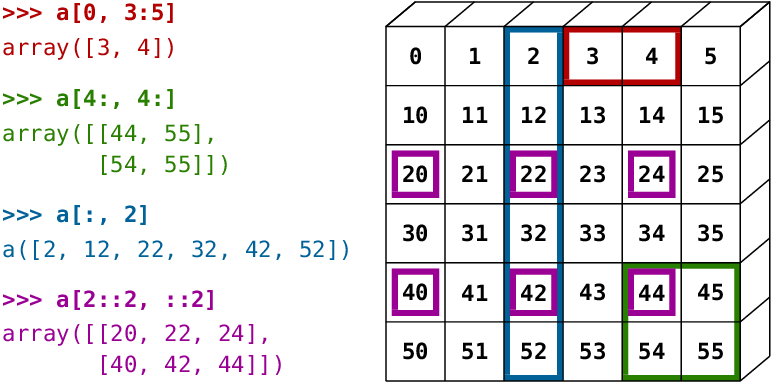

할당과 슬라이싱을 함께 사용할 수도 있다:

In [66]:
a = np.arange(10)
a

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [67]:
a[5:] = 10
a

array([ 0,  1,  2,  3,  4, 10, 10, 10, 10, 10])

In [68]:
b = np.arange(5)
b

array([0, 1, 2, 3, 4])

In [ ]:
a[5:] = b[::-1] #역순으로 할당
a

array([0, 1, 2, 3, 4, 4, 3, 2, 1, 0])

## 2.1.6. Copies and views

슬라이싱 연산은 원본 array에 대한 뷰(view)를 생성하며, 이는 array에 접근하는 하나의 방식일 뿐이다.   
따라서 원본 array가 메모리에 복사(copy)되지 않는다. 두 배열이 같은 메모리 블록을 공유하는지 확인하려면 `np.may_share_memory()` 함수를 사용할 수 있다.

Numpy Array : View(메모리 공유)  -> 원본영향 O. 
List.       : Copy(새 객체 생성) -> 원본영향 X  
Dictionary  : slicing 불가  

**뷰(view)를 수정하면 원본 array도 함께 수정된다!**

In [70]:
a = np.arange(10)
a

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [ ]:
b = a[::2]
b  # a의 0, 2, 4, 6, 8 번째 원소로 구성된 배열 : 기존 array를 그대로 참조함 

array([0, 2, 4, 6, 8])

In [71]:
np.may_share_memory(a, b)

False

In [73]:
b[0] = 12
b

array([12,  2,  4,  6,  8])

In [ ]:
a  # b를 수정하면 a도 수정된다. list slicing과 달리 array slicing은 원본 array의 데이터를 참조하기 때문이다.

array([12,  1,  2,  3,  4,  5,  6,  7,  8,  9])

In [75]:
a = np.arange(10)
c = a[::2].copy()    # force a copy
c[0] = 12
a

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [76]:
np.may_share_memory(a, c)

False

이러한 작동 방식은 처음에는 다소 놀라울 수 있지만, 메모리와 시간을 모두 절약할 수 있다는 장점이 있다.

## 2.1.7. Fancy indexing

NumPy array는 슬라이스뿐만 아니라 boolean 혹은 integer arrays(마스크)로도 인덱싱할 수 있다. 이러한 방법을 **팬시 인덱싱(fancy indexing)**이라고 하며, 이 경우에는 **뷰(view)**가 아닌 **복사본(copy)**이 생성된다.

**Boolean 마스크를 이용한 인덱싱:**

In [77]:
rng = np.random.default_rng(27446968)
a = rng.integers(0, 21, 15)
a

array([ 3, 13, 12, 10, 10, 10, 18,  4,  8,  5,  6, 11, 12, 17,  3])

In [78]:
(a % 3 == 0)

array([ True, False,  True, False, False, False,  True, False, False,
       False,  True, False,  True, False,  True])

In [79]:
mask = (a % 3 == 0)
extract_from_a = a[mask]
extract_from_a

array([ 3, 12, 18,  6, 12,  3])

마스크를 이용한 인덱싱은 sub-array에 새로운 값을 할당할 때 매우 유용하다.

In [80]:
a[a % 3 == 0] = -1
a

array([-1, 13, -1, 10, 10, 10, -1,  4,  8,  5, -1, 11, -1, 17, -1])

**Integer 마스크를 이용한 인덱싱:**

In [85]:
a = np.arange(0, 100, 10)
a

array([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])

동일한 인덱스를 여러 번 반복하여 인덱싱을 수행할 수도 있다.

In [87]:
a[[2, 3, 2, 4, 2]]    # note: [2, 3, 2, 4, 2] is a Pytohn list

array([20, 30, 20, 40, 20])

새로운 값의 할당 역시 가능하다.


In [88]:
a[[9, 7]] = -100
a

array([   0,   10,   20,   30,   40,   50,   60, -100,   80, -100])

Integer array를 이용해 인덱싱하는 경우, 생성되는 새로운 array는 그 integer array와 동일한 형태(shape)를 가진다.

In [89]:
a = np.arange(10)
a

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [90]:
idx = np.array([[3, 4], [9, 7]])
idx, idx.shape

(array([[3, 4],
        [9, 7]]),
 (2, 2))

In [91]:
a[idx]

array([[3, 4],
       [9, 7]])

팬시 인덱싱(fancy indexing)의 다양한 활용 예시:<br>

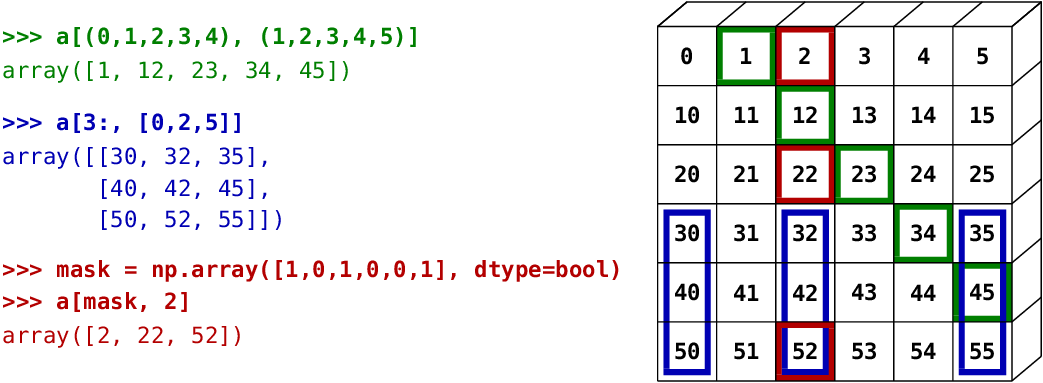

## Exercise 1

다음의 2차원 array를 (직접 입력하지 않고) 생성하시오: <br>
```
[[1,  6, 11],
 [2,  7, 12],
 [3,  8, 13],
 [4,  9, 14],
 [5, 10, 15]]
```


In [98]:
A = np.arange(1,16).reshape((5,3), order='F')
A

array([[ 1,  6, 11],
       [ 2,  7, 12],
       [ 3,  8, 13],
       [ 4,  9, 14],
       [ 5, 10, 15]])

위에서 생성한 array의 2번째와 4번째 행을 포함하는 새로운 array를 생성하시오.

In [ ]:
# 내 답변 
A2 = A[[2,4]]
A2

array([[ 2,  7, 12],
       [ 4,  9, 14]])

In [ ]:
# 교수님 답변 
A2 = A[[1,3],:]
A2

array([[ 2,  7, 12],
       [ 4,  9, 14]])

# 2.2. Numerical operations on arrays

## 2.2.1. Elementwise operations

**Basic operations:**

*   scalars와의 연산:

In [105]:
a = np.array([1, 2, 3, 4])
a + 1

array([2, 3, 4, 5])

In [106]:
2 ** a

array([ 2,  4,  8, 16])

In [107]:
a

array([1, 2, 3, 4])

*   모든 산술 연산은 요소별로(elementwise) 수행된다:

In [108]:
b = np.ones(4) + 1
b

array([2., 2., 2., 2.])

In [109]:
a - b

array([-1.,  0.,  1.,  2.])

In [110]:
a * b

array([2., 4., 6., 8.])

In [111]:
j = np.arange(5)
j

array([0, 1, 2, 3, 4])

In [112]:
2 ** (j + 1) - j

array([ 2,  3,  6, 13, 28])

이러한 연산은 순수 파이썬으로 수행할 때보다 훨씬 빠르다:

In [113]:
a = np.arange(10000)
%timeit a + 1
l = range(10000)
%timeit [i+1 for i in l]

1.73 μs ± 15.2 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
219 μs ± 3.01 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


**주의: 배열 곱셈은 행렬 곱셈이 아니다.**

#### c * c : element간의 곱셈 , c @ c : 행렬간의 곱셈 

In [114]:
c = np.ones((3, 3))
c * c

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])

행렬 곱셈은 다음과 같다:

In [115]:
c @ c

array([[3., 3., 3.],
       [3., 3., 3.],
       [3., 3., 3.]])

**Other operations:**

*   비교 연산: element wise 

In [116]:
a = np.array([1, 2, 3, 4])
b = np.array([4, 2, 2, 4])
a, b

(array([1, 2, 3, 4]), array([4, 2, 2, 4]))

In [ ]:
a == b # 각각의 element-wise 비교 결과를 담은 boolean array 반환

array([False,  True, False,  True])

In [118]:
a > b

array([False, False,  True, False])

#### Array-wise 비교 연산: np.array_equal

In [119]:
a = np.array([1, 2, 3, 4])
b = np.array([4, 2, 2, 4])
c = np.array([1, 2, 3, 4])
np.array_equal(a, b)

False

In [120]:
np.array_equal(a, c)

True

*   논리 연산:

In [122]:
a = np.array([1, 1, 0, 0], dtype=bool)
b = np.array([1, 0, 1, 0], dtype=bool)
np.logical_or(a, b)

array([ True,  True,  True, False])

*   초월 함수(transcendental functions):

In [124]:
a = np.arange(5)
print(a)
print(np.sin(a))

[0 1 2 3 4]
[ 0.          0.84147098  0.90929743  0.14112001 -0.7568025 ]


In [125]:
np.exp(a)

array([ 1.        ,  2.71828183,  7.3890561 , 20.08553692, 54.59815003])

In [126]:
np.log(np.exp(a))

array([0., 1., 2., 3., 4.])

형태 불일치:

In [ ]:
a = np.arange(4)     # len 4
a + np.array([1, 2]) #len 2 

SyntaxError: invalid syntax (2713481857.py, line 1)

*   전치(transposition):

In [129]:
np.ones((3, 3))

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])

In [130]:
a = np.triu(np.ones((3, 3)), 1)
a

array([[0., 1., 1.],
       [0., 0., 1.],
       [0., 0., 0.]])

In [131]:
a.T

array([[0., 0., 0.],
       [1., 0., 0.],
       [1., 1., 0.]])

**주의: 전치(transpose)는 원본 array의 뷰(view)를 반환한다.** 
#### Array View 

In [132]:
a = np.arange(9).reshape(3, 3)
a

array([[0, 1, 2],
       [3, 4, 5],
       [6, 7, 8]])

In [133]:
a.T

array([[0, 3, 6],
       [1, 4, 7],
       [2, 5, 8]])

In [134]:
a.T[0, 2] = 999
a.T

array([[  0,   3, 999],
       [  1,   4,   7],
       [  2,   5,   8]])

In [135]:
a

array([[  0,   1,   2],
       [  3,   4,   5],
       [999,   7,   8]])

In [136]:
b = a.T.copy()    # forcing copying
b

array([[  0,   3, 999],
       [  1,   4,   7],
       [  2,   5,   8]])

참고: 선형대수
서브모듈 `numpy.linalg`는 선형 시스템 풀이, 특이값 분해(SVD) 등 기본적인 선형대수 연산을 구현한다.  
하지만 효율적인 연산 루틴으로 컴파일되어 있다고는 보장할 수 없으며, 효율적인 선형대수의 연산을 위해서는 `scipy.linalg`의 사용을 권장합니다.

## 2.2.2. Basic reductions

**Computing sums:**

In [137]:
x = np.array([1, 2, 3, 4])
np.sum(x)

np.int64(10)

In [138]:
x.sum()

np.int64(10)

행별 합과 열별 합: <br><br>

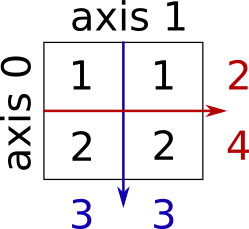

In [139]:
x = np.array([[1, 1], [2, 2]])
x

array([[1, 1],
       [2, 2]])

In [140]:
x.sum(axis = 0)    # sum across rows (first dimension)

array([3, 3])

In [141]:
x[:, 0].sum(), x[:, 1].sum()

(np.int64(3), np.int64(3))

In [142]:
x.sum(axis = 1)

array([2, 4])

In [143]:
x[0, :].sum(), x[1, :].sum()

(np.int64(2), np.int64(4))

더 높은 차원에서도 같은 방식으로 작동한다:

axis = 0 : depth  
axis = 1 : rows  
axis = 2 : columns 

In [145]:
rng = np.random.default_rng(27446968)
x = rng.random((2, 2, 2))
x

array([[[0.64613018, 0.48984931],
        [0.50851229, 0.22563948]],

       [[0.27567831, 0.53656835],
        [0.81055379, 0.92206861]]])

In [146]:
x.sum(axis = 2)

array([[1.13597949, 0.73415176],
       [0.81224666, 1.73262241]])

In [147]:
x[0, 1, :].sum()

np.float64(0.7341517644004746)

In [148]:
x = np.array([[1, 2, 3,], [4, 6, 8]])
x

array([[1, 2, 3],
       [4, 6, 8]])

In [149]:
x.cumsum(axis = 1)

array([[ 1,  3,  6],
       [ 4, 10, 18]])

**Other reductions:**

동일한 방식으로 작동한다. 또한 `axis=` 인자를 사용할 수 있다.

*   최대값과 최소값(extrema):

In [ ]:
x = np.array([1, 3, 2])
print(x.min())
print(x.max())

1
3


In [151]:
print(x.argmin())    # index of minimum
print(x.argmax())    # index of maximum

0
1


In [152]:
x = np.array([[1, 2, 3,], [4, 6, 8]])
x

array([[1, 2, 3],
       [4, 6, 8]])

In [153]:
x.max(axis = 1)

array([3, 8])

*   논리 연산:

In [154]:
np.all([True, True, False])

np.False_

In [155]:
np.any([True, True, False])

np.True_

배열 간의 비교에도 사용 가능하다.

In [156]:
a = np.zeros((100, 100))
a, a != 0

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(100, 100)),
 array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]], shape=(100, 100)))

In [157]:
np.any(a != 0)

np.False_

In [158]:
np.all(a == a)

np.True_

In [160]:
a = np.array([1, 2, 3, 2])
b = np.array([2, 2, 3, 2])
c = np.array([6, 4, 4, 5])


In [162]:
a <= b

array([ True,  True,  True,  True])

In [163]:
b <= c

array([ True,  True,  True,  True])

In [164]:
((a <= b) & (b <= c)).all()

np.True_

*   요약 통계량:

In [159]:
x = np.array([1, 2, 3, 1])
y = np.array([[1, 2, 3], [5, 6, 1]])
x, y

(array([1, 2, 3, 1]),
 array([[1, 2, 3],
        [5, 6, 1]]))

In [165]:
x.mean()

np.float64(1.75)

In [166]:
np.median(x)

np.float64(1.5)

In [167]:
np.median(y, axis = -1)    # last axis

array([2., 5.])

In [168]:
x.std()

np.float64(0.82915619758885)

**Worked Example: diffusion using a random walk algorithm**

간단한 1차원 랜덤 워크(random walk) 과정을 생각해 보자. 매 시간마다 워커(walker)는 동일한 확률로 왼쪽이나 오른쪽으로 한 칸 이동한다.

우리는 워커가 총 t번의 왼쪽 또는 오른쪽으로의 이동을 수행하였을 때, 원점으로부터의 평균적인 거리를 알고 싶다. 이를 알아보기 위해 여러 “워커”를 시뮬레이션할 것이며,  
이 과정을 array 연산 기법을 활용해 수행해보고자 한다.  
구체적으로는, 하나의 방향에는 각 워커의 “이동 기록(story)”을, 다른 방향에는 시간(time)을 나타내는 2차원 배열을 생성할 것이다.

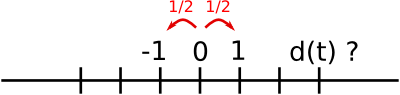

<br>

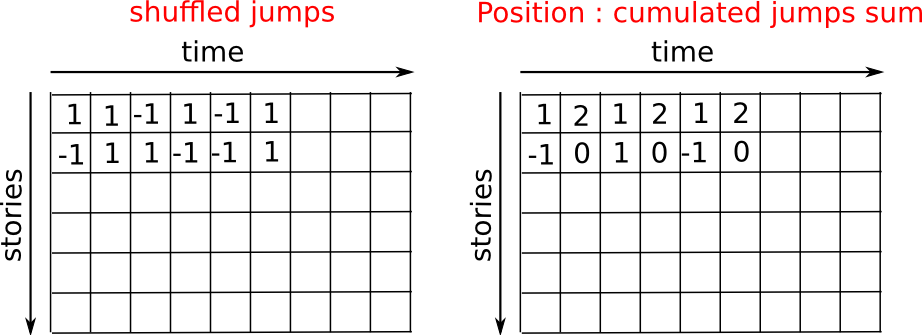

In [169]:
n_stories = 1000    # number of walkers
t_max = 200         # time during which we follow the walker

각각의 걸음에 대해 무작위로 1 또는 -1을 선택한다:

In [170]:
t = np.arange(t_max)
t

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

In [ ]:
rng.integers(0, 2, (n_stories, t_max)) # 0과 1로 이루어진 (n_stories, t_max) 크기의 array 생성

array([[1, 0, 0, ..., 0, 1, 0],
       [0, 1, 1, ..., 1, 0, 0],
       [0, 0, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 0, ..., 1, 1, 1],
       [1, 1, 0, ..., 0, 1, 0],
       [0, 1, 0, ..., 0, 0, 1]], shape=(1000, 200))

In [172]:
rng = np.random.default_rng(202505)
steps = 2 * rng.integers(0, 2, (n_stories, t_max)) - 1
steps, steps.shape

(array([[ 1,  1, -1, ..., -1, -1,  1],
        [ 1, -1, -1, ...,  1,  1, -1],
        [ 1, -1,  1, ...,  1,  1, -1],
        ...,
        [-1,  1,  1, ..., -1, -1, -1],
        [-1, -1,  1, ...,  1, -1,  1],
        [-1,  1, -1, ...,  1, -1, -1]], shape=(1000, 200)),
 (1000, 200))

In [173]:
np.unique(steps)    # verification: all steps are 1 or -1

array([-1,  1])

시간 축을 따라 걸음들을 누적 합산하여 랜덤 워크 경로를 만든다:


In [174]:
positions = np.cumsum(steps, axis = 1)    # axis = 1: dimension of time (across columns)
positions

array([[  1,   2,   1, ..., -10, -11, -10],
       [  1,   0,  -1, ...,  -6,  -5,  -6],
       [  1,   0,   1, ...,  10,  11,  10],
       ...,
       [ -1,   0,   1, ..., -18, -19, -20],
       [ -1,  -2,  -1, ...,   6,   5,   6],
       [ -1,   0,  -1, ...,  12,  11,  10]], shape=(1000, 200))

In [175]:
sq_distance = positions ** 2
sq_distance

array([[  1,   4,   1, ..., 100, 121, 100],
       [  1,   0,   1, ...,  36,  25,  36],
       [  1,   0,   1, ..., 100, 121, 100],
       ...,
       [  1,   0,   1, ..., 324, 361, 400],
       [  1,   4,   1, ...,  36,  25,  36],
       [  1,   0,   1, ..., 144, 121, 100]], shape=(1000, 200))

워커들의 이동기록(story) 축을 따라 평균을 계산한다:

In [ ]:
mean_sq_distance = np.mean(sq_distance, axis = 0) #사람에 대해서 평균을 낸다. (각 시간에 대해서)
mean_sq_distance

array([  1.   ,   2.004,   2.84 ,   3.872,   4.816,   5.908,   6.896,
         7.64 ,   8.472,   9.132,  10.096,  10.94 ,  11.792,  12.788,
        14.072,  14.72 ,  15.544,  16.784,  17.952,  19.008,  20.256,
        21.184,  22.4  ,  23.084,  23.632,  24.524,  25.264,  25.756,
        26.904,  27.984,  29.232,  30.256,  30.888,  32.392,  33.168,
        33.98 ,  35.216,  35.652,  36.44 ,  37.656,  38.768,  39.956,
        40.624,  41.596,  42.928,  43.872,  44.528,  46.276,  47.888,
        49.336,  49.816,  51.128,  51.352,  51.832,  53.448,  54.292,
        56.128,  57.16 ,  58.016,  58.612,  59.648,  60.468,  61.472,
        62.3  ,  62.872,  64.12 ,  65.776,  66.568,  67.344,  67.624,
        68.608,  69.72 ,  70.992,  71.92 ,  72.984,  73.648,  74.824,
        76.452,  76.952,  77.46 ,  78.344,  78.184,  79.48 ,  80.376,
        81.392,  82.128,  83.104,  83.76 ,  84.824,  85.208,  84.856,
        86.4  ,  88.672,  90.984,  92.664,  93.344,  93.752,  94.34 ,
        95.808,  97.

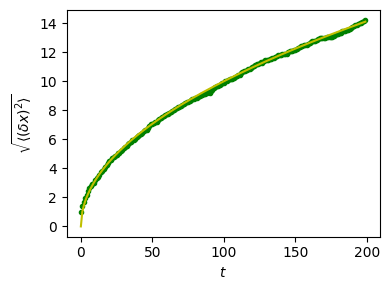

In [177]:
plt.figure(figsize = (4, 3))
plt.plot(t, np.sqrt(mean_sq_distance), 'g.', t, np.sqrt(t), 'y-')
plt.xlabel(r"$t$")
plt.ylabel(r"$\sqrt{\langle (\delta x)^2 \rangle}$")
plt.tight_layout()    # provide sufficient space for labels

우리는 물리학에서 잘 알려진 결과를 확인할 수 있다: RMS(root mean squre) 거리는 시간의 제곱근에 비례하여 증가한다!

## 2.2.3. Broadcasting

*   NumPy array에 대한 기본 연산(덧셈 등)은 원소 단위로(elementwise) 수행된다.
*   이러한 연산은 같은 크기의 array에 대해 작동한다.


하지만 NumPy가 array들의 크기를 자동으로 맞춰 줄 수 있다면, 서로 다른 크기의 array에 대해서도 연산을 수행할 수 있다. 이러한 변환 과정을 **브로드캐스팅**(**broadcasting**)이라고 한다.

아래 이미지는 브로드캐스팅의 예시를 보여준다:<br><br>
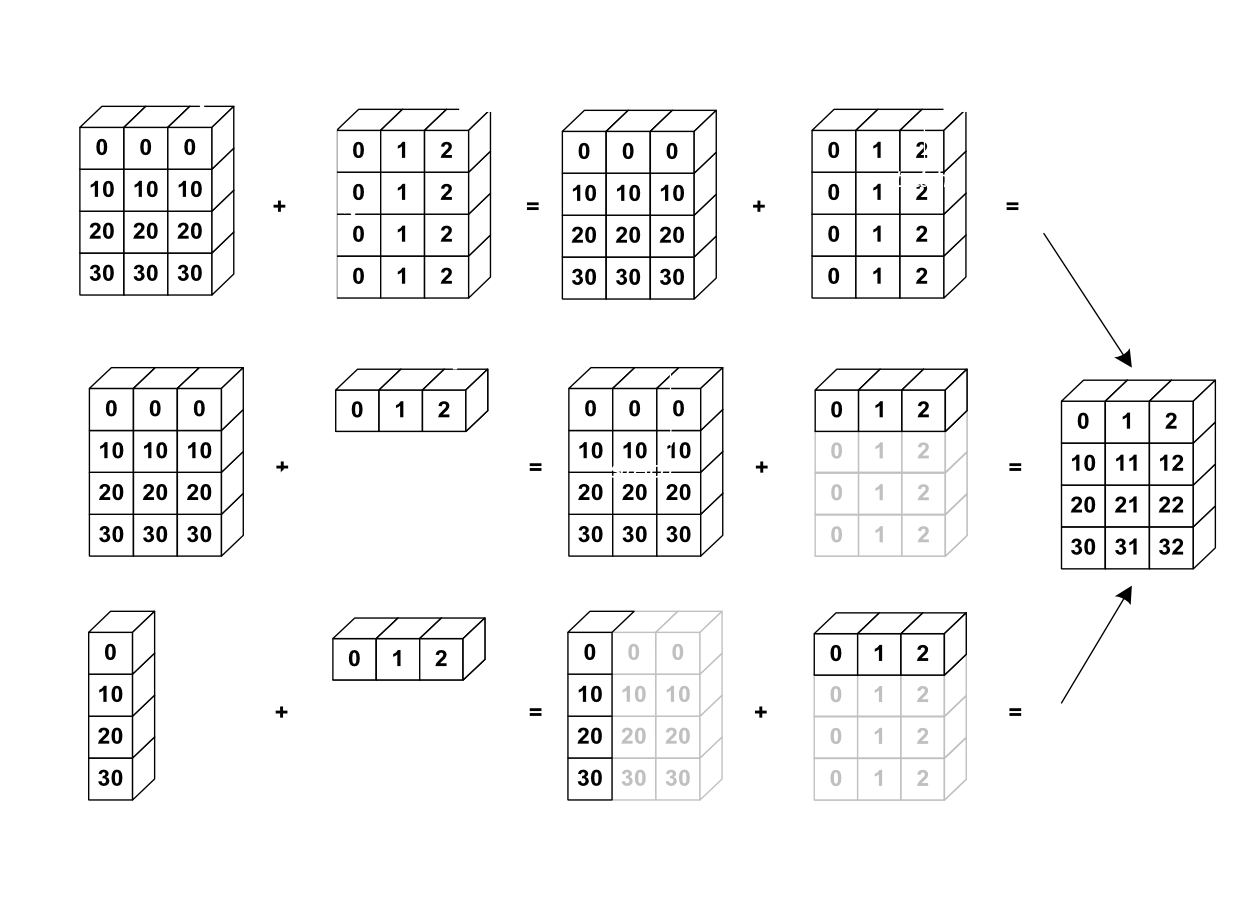

2번째 케이스  
(4,3) (3) -> (4,3) (1,3) -> (4,3) + ( 4 * 1, 3 )   
  
3번째 케이스  
(4,1) (3) -> (4,1) (1,3) -> (4, 3 * 1) + (4 * 1 ,3)

**브로드캐스팅 규칙:**

1.  차원 수가 다르면, 작은 쪽의 앞에 1을 붙여서 맞춘다. 예를 들어, (3,) → (1, 3)으로 변환
2.  각 차원마다, 두 값이 같거나, 둘 중 하나가 1이면 OK, 아니면 에러 발생
3.  연산 시, 크기 1인 축은 자동으로 반복됨(replicated)

In [ ]:
np.tile(np.arange(0, 40, 10), (3, 1)) # np.tile 포함된 array를 3 by 4 array로 복제한다. 3 번 반복

array([[ 0, 10, 20, 30],
       [ 0, 10, 20, 30],
       [ 0, 10, 20, 30]])

In [179]:
a = np.tile(np.arange(0, 40, 10), (3, 1)).T
a

array([[ 0,  0,  0],
       [10, 10, 10],
       [20, 20, 20],
       [30, 30, 30]])

In [181]:
b = np.array([0, 1, 2])
b

array([0, 1, 2])

In [182]:
a + b

array([[ 0,  1,  2],
       [10, 11, 12],
       [20, 21, 22],
       [30, 31, 32]])

우리는 이미 브로드캐스팅을 사용해본 경험이 있다:

In [183]:
a = np.ones((4, 5))
a[0] = 2    # we assign an array of dimension 0 to an array of dimension 1
a

array([[2., 2., 2., 2., 2.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.]])

유용한 트릭:

In [ ]:
a = np.arange(0, 40, 10)
a, a.shape  #row vector 라서 브로드캐스팅이 되지 않음

(array([ 0, 10, 20, 30]), (4,))

In [186]:
a = a[:, np.newaxis]     # adds a new axis -> 2D array
a, a.shape

(array([[[ 0]],
 
        [[10]],
 
        [[20]],
 
        [[30]]]),
 (4, 1, 1))

In [187]:
b

array([0, 1, 2])

In [ ]:
a + b

브로드캐스팅은 다소 마법처럼 보이기도 하지만, 실제로는 출력 데이터가 입력 데이터보다 더 많은 차원을 가진 array인 문제를 해결할 때 아주 자연스럽게 사용할 수 있습니다.

**Worked Example: Broadcasting**

Route 66에 있는 도시들인 Chicago, Springfield, Saint-Louis, Tulsa, Oklahoma City, Amarillo, Santa Fe, Albuquerque, Flagstaff, Los Angeles 간의 거리(마일 단위)에 대한 array를 만들어 보자. <br><br>
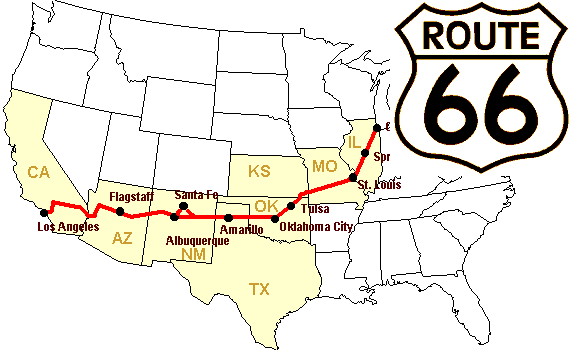

In [188]:
mileposts = np.array([0, 198, 303, 736, 871, 1175, 1475, 1544, 1913, 2448])
mileposts

array([   0,  198,  303,  736,  871, 1175, 1475, 1544, 1913, 2448])

In [189]:
mileposts[:, np.newaxis]

array([[   0],
       [ 198],
       [ 303],
       [ 736],
       [ 871],
       [1175],
       [1475],
       [1544],
       [1913],
       [2448]])

In [ ]:
distance_array = np.abs(mileposts - mileposts[:, np.newaxis])
distance_array

#row 1이 시카고와 다른 도시 사이의 거리 

array([[   0,  198,  303,  736,  871, 1175, 1475, 1544, 1913, 2448],
       [ 198,    0,  105,  538,  673,  977, 1277, 1346, 1715, 2250],
       [ 303,  105,    0,  433,  568,  872, 1172, 1241, 1610, 2145],
       [ 736,  538,  433,    0,  135,  439,  739,  808, 1177, 1712],
       [ 871,  673,  568,  135,    0,  304,  604,  673, 1042, 1577],
       [1175,  977,  872,  439,  304,    0,  300,  369,  738, 1273],
       [1475, 1277, 1172,  739,  604,  300,    0,   69,  438,  973],
       [1544, 1346, 1241,  808,  673,  369,   69,    0,  369,  904],
       [1913, 1715, 1610, 1177, 1042,  738,  438,  369,    0,  535],
       [2448, 2250, 2145, 1712, 1577, 1273,  973,  904,  535,    0]])

많은 격자 기반(grid-based) 또는 네트워크 기반(network-based) 문제들에 대해서도 브로드캐스팅을 활용할 수 있다.   
예를 들어, 5x5 격자 위의 각 점에서 원점까지의 거리를 계산하고자 할 때, 다음과 같이 프로그래밍 할 수 있다.

In [191]:
x, y = np.arange(5), np.arange(5)[:, np.newaxis]
x, y

(array([0, 1, 2, 3, 4]),
 array([[0],
        [1],
        [2],
        [3],
        [4]]))

In [192]:
distance = np.sqrt(x ** 2 + y ** 2)
distance

array([[0.        , 1.        , 2.        , 3.        , 4.        ],
       [1.        , 1.41421356, 2.23606798, 3.16227766, 4.12310563],
       [2.        , 2.23606798, 2.82842712, 3.60555128, 4.47213595],
       [3.        , 3.16227766, 3.60555128, 4.24264069, 5.        ],
       [4.        , 4.12310563, 4.47213595, 5.        , 5.65685425]])

이를 색상으로 표현하면:

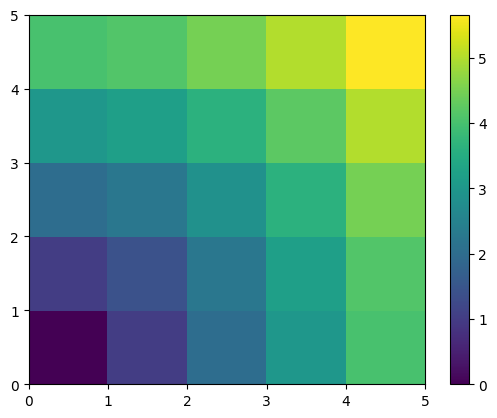

In [193]:
plt.pcolor(distance)
plt.colorbar()

`numpy.ogrid()` 함수를 사용하여 앞의 예제에서 사용된 `x`와 `y` 벡터를 두 개의 “의미 있는 차원”을 가진 형태로 직접 생성할 수 있다.

In [194]:
x, y = np.ogrid[0:5, 0:5]
x, y

(array([[0],
        [1],
        [2],
        [3],
        [4]]),
 array([[0, 1, 2, 3, 4]]))

In [195]:
x.shape, y.shape

((5, 1), (1, 5))

In [196]:
distance = np.sqrt(x ** 2 + y ** 2)
distance

array([[0.        , 1.        , 2.        , 3.        , 4.        ],
       [1.        , 1.41421356, 2.23606798, 3.16227766, 4.12310563],
       [2.        , 2.23606798, 2.82842712, 3.60555128, 4.47213595],
       [3.        , 3.16227766, 3.60555128, 4.24264069, 5.        ],
       [4.        , 4.12310563, 4.47213595, 5.        , 5.65685425]])

## 2.2.4. Array shape manipulation

**Flattening:**

In [2]:
a = np.array([[1, 2, 3], [4, 5, 6]])
a

array([[1, 2, 3],
       [4, 5, 6]])

In [3]:
a.ravel()

array([1, 2, 3, 4, 5, 6])

In [4]:
a.T ,a.T.ravel()

(array([[1, 4],
        [2, 5],
        [3, 6]]),
 array([1, 4, 2, 5, 3, 6]))

고차원 배열: 마지막 차원이 “먼저” 펼쳐(ravel)진다.

**Reshaping:**

*   평탄화(flattening)의 역연산:

In [9]:
a, a.shape

(array([[1, 2, 3],
        [4, 5, 6]]),
 (2, 3))

In [10]:
b = a.ravel()
b

array([1, 2, 3, 4, 5, 6])

In [7]:
b = b.reshape((2, 3))
b

array([[1, 2, 3],
       [4, 5, 6]])

In [ ]:
b.reshape((2, 3), order = 'F') # reshape with column-major order

array([[1, 3, 5],
       [2, 4, 6]])

In [12]:
a.ravel().reshape((2, -1))     # unspecified (-1) value is inferred

array([[1, 2, 3],
       [4, 5, 6]])

**주의: `ndarray.reshape`는 뷰(view)를 반환할 수도 있고, 복사본(copy)을 반환할 수도 있다.**

메모리 저장위치 바뀌면 copy가 됨 >> 카피강제 ㅊㅊ

In [13]:
a = np.array([[1, 2, 3], [4, 5, 6]])
b = a.reshape(3, 2)
b


array([[1, 2],
       [3, 4],
       [5, 6]])

In [14]:
b[0, 0] = 99
b

array([[99,  2],
       [ 3,  4],
       [ 5,  6]])

In [15]:
a

array([[99,  2,  3],
       [ 4,  5,  6]])

In [16]:
a = np.zeros((3, 2))
a

array([[0., 0.],
       [0., 0.],
       [0., 0.]])

In [18]:
a = np.array([[1, 2], [3, 4], [5, 6]])
a

array([[1, 2],
       [3, 4],
       [5, 6]])

In [21]:
b = a.T.reshape(3 * 2)
b


array([1, 3, 5, 2, 4, 6])

In [22]:
b[0] = 9
b

array([9, 3, 5, 2, 4, 6])

In [23]:
a

array([[1, 2],
       [3, 4],
       [5, 6]])

**Adding a dimension:**

앞서 브로드캐스팅 섹션에서 살펴본 것과 같이, `np.newaxis` 객체를 사용한 인덱싱을 통해 배열에 축(axis)을 추가할 수 있다:

In [ ]:
z = np.array([1, 2, 3])
z

In [ ]:
z[:, np.newaxis]

In [ ]:
z[np.newaxis, :]

**Dimension shuffling:**

In [ ]:
a = np.arange(4 * 3 * 2).reshape(4, 3, 2)
a, a.shape

In [ ]:
a[0, 2, 1]

In [ ]:
b = a.transpose(1, 2, 0)
b.shape

In [ ]:
b[2, 1, 0]

`array.transpose()`는 뷰를 생성한다.

In [ ]:
b[2, 1, 0] = -1
a[0, 2, 1]

**Resizing:**

Array의 크기는 `ndarray.resize`를 사용하여 변경할 수 있다:

In [ ]:
ndarray = np.arange(27)

In [ ]:
ndarray.resize((50,)) # 0 으로 채워진 50개의 원소를 가지는 array로 크기 변경

하지만 해당 array가 다른 곳에서 참조되고 있으면 `ndarray.resize`를 사용할 수 없다:

In [ ]:
b = a
a.resize(8, )

## 2.2.5. Sorting data

*   축을 따라 정렬하기:

In [24]:
a = np.array([[4, 3, 5], [1, 2, 1]])
a

array([[4, 3, 5],
       [1, 2, 1]])

In [25]:
b = np.sort(a, axis = 1)
a, b

(array([[4, 3, 5],
        [1, 2, 1]]),
 array([[3, 4, 5],
        [1, 1, 2]]))

*   In-place 정렬:

In [26]:
a.sort(axis = 1)
a

array([[3, 4, 5],
       [1, 1, 2]])

*   팬시 인덱싱(fancy indexing)을 이용한 정렬:

In [27]:
a = np.array([4, 3, 1, 2])
j = np.argsort(a)
j

array([2, 3, 1, 0])

In [28]:
a[j]

array([1, 2, 3, 4])

## 2.2.6. Summary

**무엇을 알아야 하는가?**

*   Array를 생성하는 방법을 알아야 한다: `array`, `arange`, `ones`, `zeros`.
*   Array의 형태는 `array.shape`으로 확인하며, 슬라이싱을 사용하여 배열의 다양한 뷰를 얻을 수 있다 (예를 들어 `array[::2]` 등). Array의 형태를 변경하려면 `reshape`을 사용하고, 평탄화(flatten)하려면 `ravel`을 사용하자.
*   마스크(mask)를 이용해 array의 일부 요소를 선택하거나 해당 값들을 수정할 수 있다.
*   Array에 대한 다양한 연산도 알아두어야 한다. 예를 들어, 최댓값이나 평균을 구하는 `array.max()`, `array.mean()` 같은 함수들이 있다. 모든 내용을 기억할 필요는 없지만, 필요할 때마다 온라인 문서나 help() 함수를 찾아보는 습관을 들이는 것이 좋다!
*   좀 더 발전된 Numpy의 사용을 위해서는 integer arrays을 이용한 인덱싱과 브로드캐스팅(broadcasting)을 익히는 것이 좋다.

## Exercise 2

```
import numpy as np
a = np.arange(25).reshape(5, 5)
```
위의 array의 각 열을 array `b = np.array([1., 5, 10, 15, 20])`로 원소별로(elementwise) 나누시오.

In [ ]:
# 내 답변 : 틀렸음. 각 행을 나눠줬음. 
import numpy as np
a = np.arange(25).reshape(5, 5)
b = np.array([1.,5,10,15,20])
print(a)
print(b)
print(a / b)

[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]
 [20 21 22 23 24]]
[ 1.  5. 10. 15. 20.]
[[ 0.          0.2         0.2         0.2         0.2       ]
 [ 5.          1.2         0.7         0.53333333  0.45      ]
 [10.          2.2         1.2         0.86666667  0.7       ]
 [15.          3.2         1.7         1.2         0.95      ]
 [20.          4.2         2.2         1.53333333  1.2       ]]


In [199]:
# 교수님 
b[:, np.newaxis]


array([[ 1.],
       [ 5.],
       [10.],
       [15.],
       [20.]])

In [200]:
a / b[:, np.newaxis]

array([[0.        , 1.        , 2.        , 3.        , 4.        ],
       [1.        , 1.2       , 1.4       , 1.6       , 1.8       ],
       [1.        , 1.1       , 1.2       , 1.3       , 1.4       ],
       [1.        , 1.06666667, 1.13333333, 1.2       , 1.26666667],
       [1.        , 1.05      , 1.1       , 1.15      , 1.2       ]])

## Exercise 3

[0, 1] 사이의 균등분포(uniform distribution)에서 난수를 생성하여 10 x 5 배열을 만들고, 각 행에서 0.5에 가장 가까운 숫자를 찾아내보고자 한다.

*   각 행에서 0.5에 가장 가까운 열 j를 찾기 위해 `abs`와 `argmin`을 사용하시오.
*   그리고 팬시 인덱싱(fancy indexing)을 사용하여 해당 숫자들을 추출하시오.

In [32]:
rng = np.random.default_rng(202505)
a = rng.random((10, 5))
a

array([[0.95098133, 0.97651126, 0.21038334, 0.35265993, 0.42942311],
       [0.44480287, 0.38585735, 0.754443  , 0.24522981, 0.57165706],
       [0.23192416, 0.24830281, 0.02545357, 0.4683767 , 0.77402196],
       [0.14467509, 0.40205056, 0.55498794, 0.52154454, 0.72797398],
       [0.11243319, 0.61486338, 0.58433178, 0.14957089, 0.43982227],
       [0.06911303, 0.83076342, 0.5959485 , 0.80690454, 0.3722231 ],
       [0.60991894, 0.13946392, 0.69607297, 0.91497384, 0.27574784],
       [0.21036279, 0.3773952 , 0.70707908, 0.66802984, 0.56422352],
       [0.52284419, 0.38858132, 0.36830818, 0.72195977, 0.79682158],
       [0.50637901, 0.28000206, 0.80784532, 0.04256429, 0.65333903]])

In [33]:
a2 = a.copy()
a2 -= 0.5

In [34]:
a[a2.abs.argmin()]

AttributeError: 'numpy.ndarray' object has no attribute 'abs'

In [36]:
jj = np.argmin(np.abs(a-0.5), axis = 1)    # column-wise argmin
a[np.arange(10),jj]

array([0.42942311, 0.44480287, 0.4683767 , 0.52154454, 0.43982227,
       0.5959485 , 0.60991894, 0.56422352, 0.52284419, 0.50637901])

# 2.3. More bout NumPy

## 2.3.1. More with data types

**Casting:**

서로 다름 자료형(data types) 간의 연산에서는 더 “큰” 자료형이 우선한다:

In [37]:
np.array([1, 2, 3]) + 1.5

array([2.5, 3.5, 4.5])

In [38]:
a = np.array([1, 2, 3])
a.dtype

dtype('int64')

할당(assignment)은 자료형(type)을 변경하지 않는다:

In [39]:
a[0] = 1.9    # <-- float is truncated to integer
a

array([1, 2, 3])

강제 형 변환(forced casts):

In [ ]:
a = np.array([1.7, 1.2, 1.6])
b = a.astype(int)    # <-- truncates to integer
b

반올림(rounding):

In [ ]:
a = np.array([1.2, 1.5, 1.6, 2.5, 3.5, 4.5])
b = np.around(a)
b                   # still floating-point

In [ ]:
c = np.around(a).astype(int)
c

## 2.3.2. maskedarray: dealing with (propagation of) missing data

maskedarray는 NumPy array에서 일부 원소를 "무시(missing or invalid)"할 수 있게 해주는 객체이다. 즉, 결측값이나 계산에서 제외할 값을 마스크(mask)를 이용해 처리할 수 있도록 만든 특수한 배열이다.

float의 경우 NaN을 사용할 수도 있지만, 마스크는 모든 자료형에 대해 작동한다.

In [ ]:
x = np.ma.array([1, 2, 3, 4], mask = [0, 1, 0, 1])
x

In [ ]:
y = np.ma.array([1, 2, 3, 4], mask = [0, 1, 1, 1])
y

In [ ]:
x + y

일반 함수들의 마스킹 버전:

In [ ]:
np.ma.sqrt([1, -1, 2, -2])

# 2.4. Advanced operations

## 2.4.1. Polynomials

NumPy에는 다양한 기저(bases)의 다항식도 포함되어 있다:


예를 들어, $3x^2 + 2x - 1$:

In [40]:
p = np.poly1d([3, 2, -1])
p(0)

np.int64(-1)

In [ ]:
p.roots

In [ ]:
p.order

In [ ]:
x = np.linspace(0, 1, 30)
rng = np.random.default_rng(202505)
y = np.cos(x) + 0.3 * rng.random(30)
p = np.poly1d(np.polyfit(x, y, 3))

In [ ]:
t = np.linspace(0, 1, 200)    # use a larger number of points for smoother plotting
plt.plot(x, y, 'o', t, p(t), '-')

참고: [https://numpy.org/doc/stable/reference/routines.polynomials.poly1d.html](https://numpy.org/doc/stable/reference/routines.polynomials.poly1d.html)

## 2.4.2. Loading data files

**Text files:**

In [44]:
data = np.loadtxt('populations.txt')
data

array([[ 1900., 30000.,  4000., 48300.],
       [ 1901., 47200.,  6100., 48200.],
       [ 1902., 70200.,  9800., 41500.],
       [ 1903., 77400., 35200., 38200.],
       [ 1904., 36300., 59400., 40600.],
       [ 1905., 20600., 41700., 39800.],
       [ 1906., 18100., 19000., 38600.],
       [ 1907., 21400., 13000., 42300.],
       [ 1908., 22000.,  8300., 44500.],
       [ 1909., 25400.,  9100., 42100.],
       [ 1910., 27100.,  7400., 46000.],
       [ 1911., 40300.,  8000., 46800.],
       [ 1912., 57000., 12300., 43800.],
       [ 1913., 76600., 19500., 40900.],
       [ 1914., 52300., 45700., 39400.],
       [ 1915., 19500., 51100., 39000.],
       [ 1916., 11200., 29700., 36700.],
       [ 1917.,  7600., 15800., 41800.],
       [ 1918., 14600.,  9700., 43300.],
       [ 1919., 16200., 10100., 41300.],
       [ 1920., 24700.,  8600., 47300.]])

In [45]:
np.savetxt('pop2.txt', data)
data2 = np.loadtxt('pop2.txt')

In [46]:
data2

array([[ 1900., 30000.,  4000., 48300.],
       [ 1901., 47200.,  6100., 48200.],
       [ 1902., 70200.,  9800., 41500.],
       [ 1903., 77400., 35200., 38200.],
       [ 1904., 36300., 59400., 40600.],
       [ 1905., 20600., 41700., 39800.],
       [ 1906., 18100., 19000., 38600.],
       [ 1907., 21400., 13000., 42300.],
       [ 1908., 22000.,  8300., 44500.],
       [ 1909., 25400.,  9100., 42100.],
       [ 1910., 27100.,  7400., 46000.],
       [ 1911., 40300.,  8000., 46800.],
       [ 1912., 57000., 12300., 43800.],
       [ 1913., 76600., 19500., 40900.],
       [ 1914., 52300., 45700., 39400.],
       [ 1915., 19500., 51100., 39000.],
       [ 1916., 11200., 29700., 36700.],
       [ 1917.,  7600., 15800., 41800.],
       [ 1918., 14600.,  9700., 43300.],
       [ 1919., 16200., 10100., 41300.],
       [ 1920., 24700.,  8600., 47300.]])

**Images:**

Matplotlib를 사용:

In [50]:
import matplotlib.pyplot as plt

In [52]:
img = plt.imread('elephant.png')
img.shape, img.dtype

((200, 300, 3), dtype('float32'))

In [58]:
img[::6,::6].shape

(34, 50, 3)

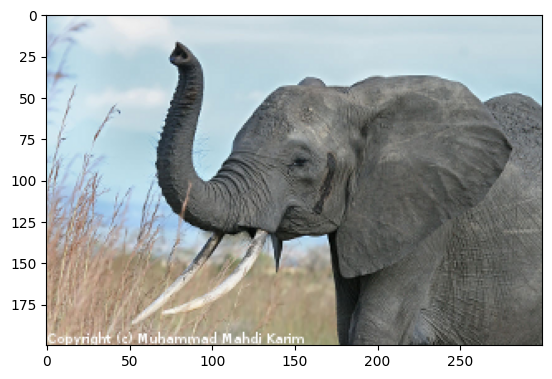

In [53]:
plt.imshow(img)
plt.savefig('plot.png')

RGB의 채널 중 하나만 저장:

In [57]:
img[:,:,0].shape

(200, 300)

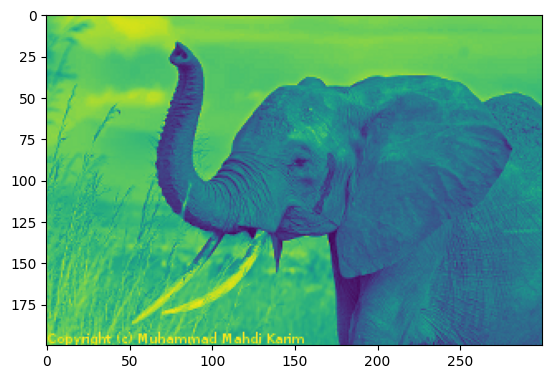

In [54]:
plt.imsave('red_elephant.png', img[:,:,0])
plt.imshow(plt.imread('red_elephant.png'))

저해상도 이미지 생성:

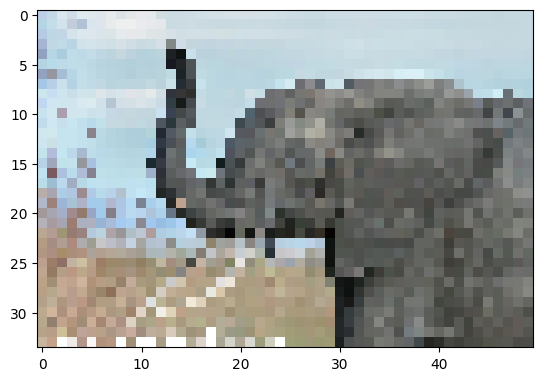

In [55]:
plt.imsave('tiny_elephant.png', img[::6,::6])
plt.imshow(plt.imread('tiny_elephant.png'))

## Exercise 4

**데이터 통계:** `populations.txt` 파일에 있는 데이터는 캐나다 북부 지역에서 20년 동안의 토끼(hare), 스라소니(lynx), 당근(carrot)의 개체 수를 보여준다.

In [62]:
data.T

array([[ 1900.,  1901.,  1902.,  1903.,  1904.,  1905.,  1906.,  1907.,
         1908.,  1909.,  1910.,  1911.,  1912.,  1913.,  1914.,  1915.,
         1916.,  1917.,  1918.,  1919.,  1920.],
       [30000., 47200., 70200., 77400., 36300., 20600., 18100., 21400.,
        22000., 25400., 27100., 40300., 57000., 76600., 52300., 19500.,
        11200.,  7600., 14600., 16200., 24700.],
       [ 4000.,  6100.,  9800., 35200., 59400., 41700., 19000., 13000.,
         8300.,  9100.,  7400.,  8000., 12300., 19500., 45700., 51100.,
        29700., 15800.,  9700., 10100.,  8600.],
       [48300., 48200., 41500., 38200., 40600., 39800., 38600., 42300.,
        44500., 42100., 46000., 46800., 43800., 40900., 39400., 39000.,
        36700., 41800., 43300., 41300., 47300.]])

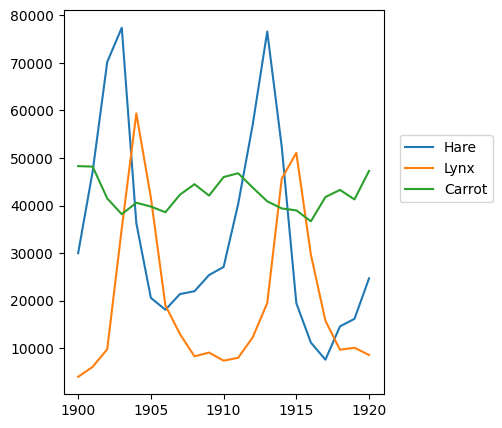

In [60]:
data = np.loadtxt('populations.txt')
year, hares, lynxes, carrots = data.T        # trick: columns to variables

import matplotlib.pyplot as plt
plt.axes([0.2, 0.1, 0.5, 0.8])
plt.plot(year, hares, year, lynxes, year, carrots)
plt.legend(('Hare', 'Lynx', 'Carrot'), loc=(1.05, 0.5))



1.   기간 동안 각 종(species)의 개체 수에 대한 평균(mean)과 표준편차(std)를 계산하고 출력하시오.
2.   각 종이 가장 많은 개체수를 가졌던 해를 구하시오.
3.   각 연도별로 개체수가 가장 많은 종을 구하시오. (힌트: `argsort`와 `np.array(['H', 'L', 'C'])`에 대한 팬시 인덱싱 사용하시오)
4.   어느 해든 어떤 종이라도 개체수가 50,000을 초과한 해들을 구하시오. (힌트: 비교 연산과 `np.any` 활용하시오)
5.   각 종에 대해 개체수가 가장 적었던 해 2개씩을 구하시오. (힌트: `np.argsort`와 팬시 인덱싱 활용하시오)
6.   토끼(hare) 개체수의 변화량과 스라소니(lynx) 개체수를 비교하여 시각화(plot)하시오. (힌트: `np.gradient`를 사용하여 변화량을 계산하고,
`np.corrcoef`를 이용하여 상관관계를 확인하시오)




In [69]:
#1 각 종(species)의 개체 수에 대한 평균(mean)과 표준편차(std)를 계산하고 출력하시오.
print(np.mean(hares), np.std(hares))
print(np.mean(lynxes), np.std(lynxes))
print(np.mean(carrots), np.std(carrots))

34080.95238095238 20897.906458089667
20166.666666666668 16254.591536908763
42400.0 3322.5062255844787


In [72]:
# 교수님
population = data[:, 1:]    # all rows, columns 1 to end
population

array([[30000.,  4000., 48300.],
       [47200.,  6100., 48200.],
       [70200.,  9800., 41500.],
       [77400., 35200., 38200.],
       [36300., 59400., 40600.],
       [20600., 41700., 39800.],
       [18100., 19000., 38600.],
       [21400., 13000., 42300.],
       [22000.,  8300., 44500.],
       [25400.,  9100., 42100.],
       [27100.,  7400., 46000.],
       [40300.,  8000., 46800.],
       [57000., 12300., 43800.],
       [76600., 19500., 40900.],
       [52300., 45700., 39400.],
       [19500., 51100., 39000.],
       [11200., 29700., 36700.],
       [ 7600., 15800., 41800.],
       [14600.,  9700., 43300.],
       [16200., 10100., 41300.],
       [24700.,  8600., 47300.]])

In [74]:
#1.
np.mean(population, axis = 0)    # mean across rows (first dimension)

array([34080.95238095, 20166.66666667, 42400.        ])

In [75]:
np.std(population, axis = 0)    # std across rows (first dimension)

array([20897.90645809, 16254.59153691,  3322.50622558])

In [76]:
#2
year_max = np.argmax(population, axis = 0)    # index of maximum across rows (first dimension)
year_max

array([3, 4, 0])

In [77]:
year[year_max]

array([1903., 1904., 1900.])

In [78]:
#3 
specie_max = np.argmax(population, axis = 1)    # index of maximum across columns (second dimension
specie_max

array([2, 2, 0, 0, 1, 1, 2, 2, 2, 2, 2, 2, 0, 0, 0, 1, 2, 2, 2, 2, 2])

In [80]:
np.array(['Hare', 'Lynx', 'Carrot'])[specie_max]

array(['Carrot', 'Carrot', 'Hare', 'Hare', 'Lynx', 'Lynx', 'Carrot',
       'Carrot', 'Carrot', 'Carrot', 'Carrot', 'Carrot', 'Hare', 'Hare',
       'Hare', 'Lynx', 'Carrot', 'Carrot', 'Carrot', 'Carrot', 'Carrot'],
      dtype='<U6')

In [82]:
#4 
np.any(population > 50000, axis = 1)

array([False, False,  True,  True,  True, False, False, False, False,
       False, False, False,  True,  True,  True,  True, False, False,
       False, False, False])

In [84]:
year_ge50000 = np.any(population > 50000, axis = 1)
year[year_ge50000]

array([1902., 1903., 1904., 1912., 1913., 1914., 1915.])

In [85]:
#5
np.argsort(population, axis = 0)    # indices of sorted array across rows (first dimension)

array([[17,  0, 16],
       [16,  1,  3],
       [18, 10,  6],
       [19, 11, 15],
       [ 6,  8, 14],
       [15, 20,  5],
       [ 5,  9,  4],
       [ 7, 18, 13],
       [ 8,  2, 19],
       [20, 19,  2],
       [ 9, 12, 17],
       [10,  7,  9],
       [ 0, 17,  7],
       [ 4,  6, 18],
       [11, 13, 12],
       [ 1, 16,  8],
       [14,  3, 10],
       [12,  5, 11],
       [ 2, 14, 20],
       [13, 15,  1],
       [ 3,  4,  0]])

In [86]:
np.argsort(population, axis = 0)[:2,:]

array([[17,  0, 16],
       [16,  1,  3]])

In [87]:
year[np.argsort(population, axis = 0)[:2,:]]

array([[1917., 1900., 1916.],
       [1916., 1901., 1903.]])

In [89]:
#6 
lynxes

array([ 4000.,  6100.,  9800., 35200., 59400., 41700., 19000., 13000.,
        8300.,  9100.,  7400.,  8000., 12300., 19500., 45700., 51100.,
       29700., 15800.,  9700., 10100.,  8600.])

In [90]:
hares

array([30000., 47200., 70200., 77400., 36300., 20600., 18100., 21400.,
       22000., 25400., 27100., 40300., 57000., 76600., 52300., 19500.,
       11200.,  7600., 14600., 16200., 24700.])

In [ ]:
grand_hares = np.gradient(hares) # 각 시점에서의 개체 수의 변화량을 계산한다. (앞뒤 시점과의 차이)  
grand_hares

array([ 17200.,  20100.,  15100., -16950., -28400.,  -9100.,    400.,
         1950.,   2000.,   2550.,   7450.,  14950.,  18150.,  -2350.,
       -28550., -20550.,  -5950.,   1700.,   4300.,   5050.,   8500.])

In [94]:
np.corrcoef(grand_hares, lynxes)

array([[ 1.        , -0.91792485],
       [-0.91792485,  1.        ]])

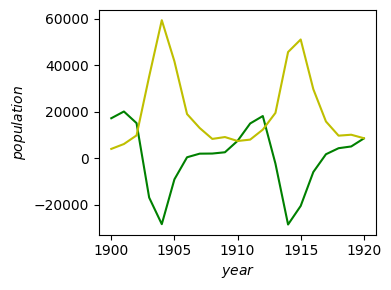

In [98]:
# 토끼(hare) 개체수의 변화량과 스라소니(lynx) 개체수를 비교하여 시각화(plot)하시오. (힌트: `np.gradient`를 사용하여 변화량을 계산하고,
# `np.corrcoef`를 이용하여 상관관계를 확인하시오)

plt.figure(figsize = (4, 3))
plt.plot(year, grand_hares, 'g-', year, lynxes, 'y-')
plt.xlabel(r"$year$")
plt.ylabel(r"$population$")
plt.tight_layout()